In [ ]:
import os
import random

import numpy as np
import pandas as pd
import scipy.io
import scipy.spatial

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import load_model

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K


In [128]:
dataset_folder = "train_data"
datasets_list = os.listdir(dataset_folder)
raw_data = []
all_observations = []
for dt in datasets_list:
  x = input()
  print(dt)
  raw_data = pd.read_csv(os.path.join(dataset_folder, dt), delimiter="\t",
                               names=["ped", "frame", "x", "y", "z"], usecols=[0, 1, 2, 3, 4], na_values="?")
  raw_data.sort_values(by=['frame', 'ped'], inplace=True)

  ped_ids = raw_data.ped.unique()
  for p in ped_ids:
      all_observations.append(raw_data[raw_data.ped == p][["x", "y", "z"]].values)


train_circle.txt
train_helix (1).txt
train_eight.txt


In [129]:
train_dataset = all_observations[0:4]
test_dataset = all_observations[4:5]

In [130]:
def euclidean_distance_loss(y_true, y_pred):
    return tf.reduce_mean(tf.sqrt(tf.reduce_sum(tf.square(y_true - y_pred), axis=1)))

In [ ]:
def sigma_y(x, ay=1, by=0.92):
    return max(ay * x**by, 0.0002)

def sigma_z(x, az=1, bz=0.87):
    return max(az * x**bz, 0.0002)

def gaussian_concentration(x, y, z, x0, y0, z0, Q=1000, u=1, H=0):
    dx = x - x0
    if dx <= 0:
        return -1  # Upwind -> no concentration

    dy = y - y0
    dz = z - z0

    sy = sigma_y(dx)
    sz = sigma_z(dx)

    term1 = Q / (2 * np.pi * u * sy * sz)
    term2 = np.exp(-dy**2 / (2 * sy**2))
    term3 = np.exp(-(dz - H)**2 / (2 * sz**2)) + np.exp(-(dz + H)**2 / (2 * sz**2))

    return term1 * term2 * term3

def random_point_on_sphere(rradius, x0, y0, z0, angle_range=np.pi/16):
    phi = np.random.uniform(-angle_range, angle_range)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)

    x = rradius * np.sin(theta) * np.cos(phi)
    y = rradius * np.sin(theta) * np.sin(phi)
    z = rradius * costheta

    return x + x0, y + y0, z + z0

def generate_balanced_data(sources):  # reduced for safety
    X_train, Y_train, concentrations, radius = [], [], [], []
    acutal_source = []
    radi = np.array([0.1, 0.15, 0.5, 1, 1.2, 1.3, 1.4, 1.5, 2, 2.5])

    for x0, y0, z0 in sources:
        acutal_source.append([x0, y0, z0])

        for r in radi:
            points = []
            concentration = []
            for offset in [0, 0.25, 0.5]:
                x, y, z = random_point_on_sphere(r + offset, x0, y0, z0)
                c = gaussian_concentration(x, y, z, x0, y0, z0)
                points.append([x, y, z])
                concentration.append(c)
                
                radius.append(r + offset)
            for i in range(3):
                concentrations.append(concentration[i])
                points[i].append(concentration[i])
            X_train.append(points)
            Y_train.append([x0, y0, z0])

    return np.array(X_train), np.array(Y_train), np.array(concentrations), np.array(radius), np.array(acutal_source)

# Run smaller-scale test
train_data = []
train_answers = []
X_dir, Y_dir, concs, rads, acutal_source = generate_balanced_data(i)
# for i in all_observations:
#     X_dir, Y_dir, concs, rads, acutal_source = generate_balanced_data(i)
#     train_data.append(X_dir)
#     train_answers.append(Y_dir)



In [ ]:
test_data = []
test_answers = []
for i in range(1):
    traj_data = []
    traj_answer = []
    for j in range(200):
        index = np.random.randint(0, 799)
        print(index)
        traj_data.append(train_data[i][index])
        traj_answer.append(train_answers[i][index])
    test_data.append(traj_data)
    test_answers.append(traj_answer)

798
535
765
166
171
306
424
776
133
241
243
352
283
254
566
577
538
257
402
757
645
383
726
427
793
602
459
127
114
379
425
395
155
304
758
696
291
542
350
162
689
150
14
102
440
388
608
163
23
101
595
505
329
182
658
352
159
114
598
193
742
308
168
516
709
766
61
123
123
559
70
705
340
444
473
458
434
703
768
150
780
644
7
447
448
386
116
735
356
661
302
756
751
63
739
677
763
557
525
571
580
797
786
153
720
116
221
515
700
588
746
361
102
58
62
368
552
189
120
75
197
40
223
108
660
352
364
299
209
473
504
508
417
205
680
529
338
624
149
481
19
422
11
554
135
777
483
295
469
752
267
187
683
618
628
545
589
175
536
165
598
659
573
63
786
129
417
385
412
268
511
7
266
459
165
298
170
519
790
250
320
363
31
311
600
207
759
324
402
645
702
269
528
419
764
379
57
95
84
193
775
495
377
309
577
665
54
541
373
245
125
119
164
77
576
64
795
360
104
99
493
613
11
116
48
619
760
336
133
701
521
391
464
194
18
321
546
319
351
216
289
349
570
720
290
729
439
606
210
366
152
458
53
115
39
571
423
6

In [134]:
print(len(test_dataset))
print(len(test_data))
print(len(train_data[-1]))
print(len(test_answers))

1
4
800
4


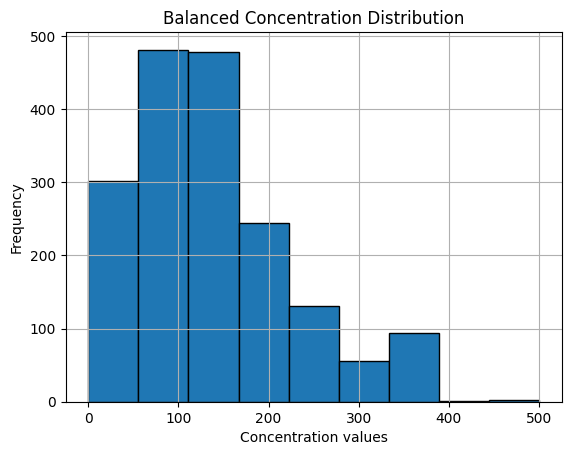

[[[ 1.16200719e+01  7.97596041e+00 -1.18481094e+00  2.70573230e+04]
  [ 1.18618402e+01  7.96345455e+00 -1.10254671e+00  2.29811617e+03]
  [ 1.21419041e+01  7.93858265e+00 -1.30100043e+00  7.98460257e+02]]

 [[ 1.16953821e+01  7.98172233e+00 -1.25558668e+00  9.50335498e+03]
  [ 1.18774362e+01  7.92591218e+00 -1.03489658e+00  1.93148454e+03]
  [ 1.17232553e+01  7.97120683e+00 -6.26082195e-01  1.35461168e+02]]

 [[ 1.20065880e+01  7.91308513e+00 -1.43231454e+00  1.18330780e+03]
  [ 1.22548246e+01  7.98186497e+00 -1.49470740e+00  5.57678445e+02]
  [ 1.21446479e+01  7.95681543e+00 -4.50972050e-01  3.64468400e+02]]

 ...

 [[ 7.12267315e+00  3.22516116e+00  5.59962763e+00  1.70050634e+02]
  [ 7.49430486e+00  3.27440749e+00  5.63723724e+00  1.28697776e+02]
  [ 8.12061460e+00  3.05060606e+00  6.89301767e+00  9.22715877e+01]]

 [[ 8.12639084e+00  2.97040983e+00  6.73782269e+00  9.21230412e+01]
  [ 8.34390811e+00  3.45639376e+00  6.77947905e+00  7.52930484e+01]
  [ 8.11045772e+00  3.31758586e+00

IndexError: list index out of range

In [ ]:
# Histogram
plt.hist(concs, bins=np.linspace(0, 500, 10), edgecolor='black')
plt.xlabel('Concentration values')
plt.ylabel('Frequency')
plt.title('Balanced Concentration Distribution')
plt.grid(True)
plt.show()

# for i in range(10):
#     print(test_data[i])
#     print(test_answers[i])

In [135]:

def euclidean_distance_loss(y_true, y_pred):
    # Mean Euclidean distance over batch
    return K.mean(K.sqrt(K.sum(K.square(y_pred - y_true), axis=-1)))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3, 4)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3)
])

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule), loss=euclidean_distance_loss)
bs = [32]
for i in bs:
    history = model.fit(train_data, train_answers, epochs=25, batch_size=i, validation_data=(test_data, test_answers), verbose=1)
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], linestyle='dashed', label='Val Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss (Euclidean Distance)")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()




Epoch 1/25


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_203
Received: inputs=('Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(shape=(32, 3, 4))', 'Tensor(

ValueError: y_true and y_pred have different structures.
y_true: ('*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*', '*',

In [ ]:
model.save('/Users/vk/source_model_6.keras')